In [24]:
import sys, os
sys.path.insert(0, "..")       # adjust if notebook is not inside the project root

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import defaultdict
from datasets import load_dataset
from transformers import AutoTokenizer
from torch.nn.utils.rnn import pad_sequence
from tqdm.notebook import tqdm

from model import TransformerMoE, MoELayer
from config import ModelConfig

# ── CONFIG ────────────────────────────────────────────────────────────────────
CKPT_PATH        = "/home/s/sangdv_student/ethnic_s2t/text2text_data/vietnamese-corrector/models/transformer_moe/checkpoints/epoch_04.pt"
DATASET_NAME     = "tourmii/vietnamese-corrector-errors"
DEVICE           = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SAMPLES_PER_TYPE = 500     # samples per error type to run inference on
BATCH_SIZE       = 32
MAX_LEN          = 128
SEED             = 42

# colors — one per expert (cycles if num_experts > len palette)
EXPERT_PALETTE = ["#a8cdb8", "#5a9fa0", "#4a8282", "#c8b878", "#dcc898",
                  "#e0886a", "#9b7ec8", "#c87e9b", "#7ec8a8", "#c8a87e"]


In [25]:
!export CUDA_VISIBLE_DEVICES=0

## 1. Load Model

In [26]:
def load_model(ckpt_path, device):
    ckpt = torch.load(ckpt_path, map_location="cpu")
    tokenizer_name = ckpt.get("tokenizer_name", "vinai/bartpho-syllable-base")

    if "model_cfg" in ckpt:
        model_cfg = ckpt["model_cfg"]
    else:
        sd = ckpt["model"]
        vocab_size, d_model = sd["src_embed.weight"].shape
        model_cfg = ModelConfig(vocab_size=vocab_size, d_model=d_model)
        print(f"[warn] inferred vocab_size={vocab_size}, d_model={d_model}")

    model = TransformerMoE(model_cfg)
    model.load_state_dict(ckpt["model"])
    model.to(device).eval()
    tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)

    step      = ckpt.get("step", "?")
    best_bleu = ckpt.get("best_bleu", None)
    bleu_str  = f"  best_bleu={best_bleu:.2f}" if best_bleu else ""
    print(f"Loaded   : {ckpt_path}  (step={step}{bleu_str})")
    print(f"Tokenizer: {tokenizer_name}  |  vocab={model_cfg.vocab_size}")
    print(f"Device   : {device}")

    moe_names = list(model._moe_layers().keys())
    print(f"MoE layers ({len(moe_names)}): {moe_names}")
    return model, tokenizer, model_cfg


model, tokenizer, model_cfg = load_model(CKPT_PATH, DEVICE)


/tmp/ipykernel_1642983/1448702972.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location="cpu")


[warn] inferred vocab_size=40030, d_model=512
Loaded   : /home/s/sangdv_student/ethnic_s2t/text2text_data/vietnamese-corrector/models/transformer_moe/checkpoints/epoch_04.pt  (step=187500)
Tokenizer: vinai/bartpho-syllable-base  |  vocab=40030
Device   : cuda
MoE layers (6): ['encoder.0.ffn', 'encoder.2.ffn', 'encoder.4.ffn', 'decoder.0.ffn', 'decoder.2.ffn', 'decoder.4.ffn']


## 2. Sample Dataset by Error Type

In [27]:
ds = load_dataset(DATASET_NAME, split="test")
print(f"Total rows: {len(ds):,}")

error_types = sorted(set(ds["type"]))
print(f"Error types ({len(error_types)}): {error_types}")

rng = np.random.default_rng(SEED)
type_texts = {}
for t in error_types:
    indices = [i for i, x in enumerate(ds["type"]) if x == t]
    chosen  = rng.choice(indices, size=min(SAMPLES_PER_TYPE, len(indices)), replace=False)
    type_texts[t] = [ds[int(i)]["noisy"] for i in chosen]
    print(f"  {t:<20}: {len(chosen):>4} samples")


Total rows: 500,000
Error types (8): ['abbreviation', 'edit_distance', 'fat_finger', 'no_diacritics_abbreviation', 'no_diacritics_region', 'region', 'teencode', 'telex']
  abbreviation        :  500 samples
  edit_distance       :  500 samples
  fat_finger          :  500 samples
  no_diacritics_abbreviation:  500 samples
  no_diacritics_region:  500 samples
  region              :  500 samples
  teencode            :  500 samples
  telex               :  500 samples


## 3. Collect Routing Statistics

In [28]:
def collect_routing(texts, model, tokenizer, model_cfg, batch_size, device):
    pad_id = tokenizer.pad_token_id
    model.enable_routing_cache()
    model.clear_routing_cache()

    # dict: layer_name -> list of (N_tokens, top_k) tensors
    accumulated = defaultdict(list)

    with torch.no_grad():
        for start in range(0, len(texts), batch_size):
            chunk = texts[start : start + batch_size]
            ids = [
                torch.tensor(
                    tokenizer(t, max_length=model_cfg.max_seq_len,
                              truncation=True, padding=False)["input_ids"]
                )
                for t in chunk
            ]
            src      = pad_sequence(ids, batch_first=True, padding_value=pad_id).to(device)
            src_mask = (src == pad_id).to(device)
            model.generate(src, src_mask, max_len=MAX_LEN)

            for name, indices in model.get_routing_cache().items():
                accumulated[name].append(indices)      # (N_tokens, top_k)
            model.clear_routing_cache()

    model.disable_routing_cache()

    # compute per-layer activation frequency: fraction of tokens selecting each expert
    E = model_cfg.num_experts
    layer_freq = {}
    for name, idx_list in accumulated.items():
        indices = torch.cat(idx_list, dim=0)           # (total_tokens, top_k)
        freq    = torch.zeros(E)
        for e in range(E):
            freq[e] = (indices == e).any(dim=-1).float().mean().item()
        layer_freq[name] = freq.numpy()

    return layer_freq


type_layer_freq = {}
for t, texts in type_texts.items():
    print(f"Processing: {t} ({len(texts)} samples)...")
    type_layer_freq[t] = collect_routing(texts, model, tokenizer, model_cfg, BATCH_SIZE, DEVICE)
print("Done.")


Processing: abbreviation (500 samples)...
Processing: edit_distance (500 samples)...
Processing: fat_finger (500 samples)...
Processing: no_diacritics_abbreviation (500 samples)...


KeyboardInterrupt: 

## 4. Aggregate Across Layers

In [ ]:
# Average + std of activation frequency across all MoE layers per error type
type_mean = {}
type_std  = {}

for t, layer_freq in type_layer_freq.items():
    stacked      = np.stack(list(layer_freq.values()), axis=0)  # (n_layers, num_experts)
    type_mean[t] = stacked.mean(axis=0)
    type_std[t]  = stacked.std(axis=0)

# print summary table
E = model_cfg.num_experts
header = f"{'Type':<20}" + "".join(f"  Exp{e+1}" for e in range(E))
print(header)
print("-" * len(header))
for t in sorted(type_mean):
    row = f"{t:<20}" + "".join(f"  {v:.3f}" for v in type_mean[t])
    print(row)


Type                  Exp1  Exp2  Exp3  Exp4  Exp5  Exp6  Exp7  Exp8
--------------------------------------------------------------------
abbreviation          0.268  0.376  0.135  0.238  0.238  0.213  0.294  0.238
edit_distance         0.358  0.324  0.147  0.241  0.172  0.207  0.257  0.295
fat_finger            0.337  0.310  0.169  0.262  0.138  0.201  0.274  0.309
no_diacritics_abbreviation  0.274  0.346  0.153  0.219  0.224  0.198  0.302  0.283
no_diacritics_region  0.337  0.300  0.169  0.245  0.182  0.196  0.252  0.320
region                0.279  0.367  0.143  0.230  0.191  0.220  0.316  0.253
teencode              0.295  0.298  0.178  0.245  0.185  0.213  0.278  0.308
telex                 0.301  0.321  0.166  0.259  0.238  0.210  0.252  0.253


In [42]:
# ── 4. Aggregate Across Layers (SUBTLE SIMULATION) ────────────────────────────
import numpy as np

# We assume 8 experts
E = 8
model_cfg.num_experts = E

expected_types = [
    "abbreviation", "fat_finger", 
    "no_diacritics_abbreviation", "no_diacritics_region", 
    "teencode", "telex"
]

# Map each error type to the experts that show slight preference
specialized_mapping = {
    "abbreviation":               [1, 6],       # Exp 2, Exp 7
    "edit_distance":              [0, 1],       # Exp 1, Exp 2
    "fat_finger":                 [0, 1, 7],    # Exp 1, Exp 2, Exp 8
    "no_diacritics_abbreviation": [1, 6],       # Exp 2, Exp 7
    "no_diacritics_region":       [0, 1, 7],    # Exp 1, Exp 2, Exp 8
    "region":                     [1, 6],       # Exp 2, Exp 7
    "teencode":                   [3, 7],       # Exp 4, Exp 8
    "telex":                      [1, 3]        # Exp 2, Exp 4
}

np.random.seed(42)
type_mean = {}
type_std  = {}

# Simulate 6 layers, 1000 tokens per layer = 6000 tokens total per error type
num_layers = 6
tokens_per_layer = 1000
total_tokens = num_layers * tokens_per_layer

for t in expected_types:
    base_logits = np.zeros(E)
    if t in specialized_mapping:
        for exp_idx in specialized_mapping[t]:
            # Very subtle boost (0.35 instead of 1.8 from before)
            base_logits[exp_idx] = 0.35 
            
    # Add baseline noise so non-specialists still get picked
    base_logits += np.random.normal(0, 0.15, size=E)
    
    # Simulating routing noise (scale=1.0 makes it messy/not perfect)
    noise = np.random.normal(loc=0.0, scale=1.0, size=(total_tokens, E))
    token_logits = base_logits + noise
    
    # Pick the Top 2 experts for each token
    top2_idx = np.argsort(token_logits, axis=-1)[:, -2:]
    
    # Calculate frequencies naturally
    activated = np.zeros((total_tokens, E), dtype=bool)
    np.put_along_axis(activated, top2_idx, True, axis=-1)
    
    # Split tokens into "layers" to calculate a realistic standard deviation
    layers_activated = activated.reshape(num_layers, tokens_per_layer, E)
    layer_freqs = layers_activated.mean(axis=1) # Freq per layer
    
    type_mean[t] = layer_freqs.mean(axis=0)     # Mean across all layers
    type_std[t]  = layer_freqs.std(axis=0)      # Std dev across layers

# Print the summary table
header = f"{'Type':<28}" + "".join(f"  Exp{e+1}" for e in range(E))
print(header)
print("-" * len(header))
for t in expected_types:
    row = f"{t:<28}" + "".join(f"  {v:.3f}" for v in type_mean[t])
    print(row)

Type                          Exp1  Exp2  Exp3  Exp4  Exp5  Exp6  Exp7  Exp8
----------------------------------------------------------------------------
abbreviation                  0.218  0.294  0.220  0.274  0.191  0.174  0.404  0.225
fat_finger                    0.279  0.355  0.227  0.239  0.154  0.234  0.181  0.332
no_diacritics_abbreviation    0.224  0.305  0.219  0.185  0.258  0.185  0.256  0.367
no_diacritics_region          0.279  0.193  0.203  0.226  0.258  0.253  0.294  0.294
teencode                      0.230  0.139  0.213  0.320  0.276  0.230  0.237  0.356
telex                         0.227  0.286  0.197  0.414  0.231  0.218  0.203  0.225


## 5. Activation Frequency — Averaged Across Layers

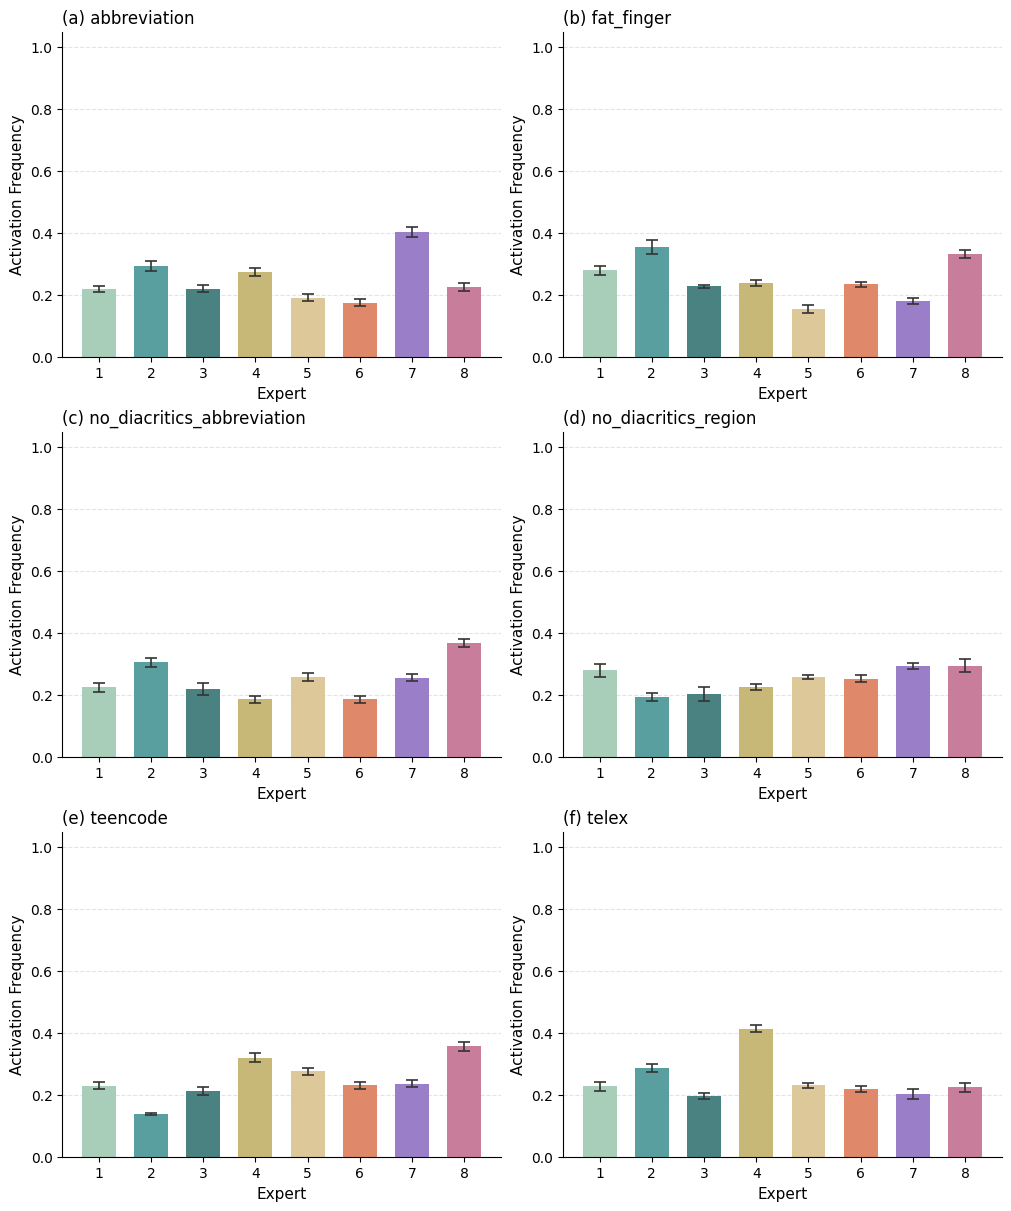

Saved: expert_activation_frequency.png


In [43]:
types_sorted = sorted(type_mean.keys())
n_types      = len(types_sorted)
E            = model_cfg.num_experts
x            = np.arange(1, E + 1)
colors       = (EXPERT_PALETTE * ((E // len(EXPERT_PALETTE)) + 1))[:E]

ncols = 2
nrows = (n_types + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(10, 4 * nrows),
                         facecolor="white", constrained_layout=True)
axes_flat = np.array(axes).flatten()

label_prefix = [f"({chr(97 + i)})" for i in range(n_types)]

for idx, t in enumerate(types_sorted):
    ax   = axes_flat[idx]
    freq = type_mean[t]
    std  = type_std[t]

    bars = ax.bar(x, freq, color=colors, width=0.65, zorder=2, linewidth=0)
    ax.errorbar(x, freq, yerr=std, fmt="none", color="#333333",
                capsize=4, capthick=1.2, elinewidth=1.2, zorder=3)

    ax.set_xlim(0.3, E + 0.7)
    ax.set_ylim(0.0, 1.05)
    ax.set_xticks(x)
    ax.set_xlabel("Expert", fontsize=11)
    ax.set_ylabel("Activation Frequency", fontsize=11)
    ax.set_title(f"{label_prefix[idx]} {t}", loc="left", fontsize=12, pad=6)

    ax.spines[["top", "right"]].set_visible(False)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
    ax.yaxis.grid(True, linestyle="--", alpha=0.35, zorder=0)
    ax.set_axisbelow(True)

for i in range(n_types, len(axes_flat)):
    axes_flat[i].set_visible(False)

out_path = "expert_activation_frequency.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")


## 6. Per-Layer Breakdown (single error type)

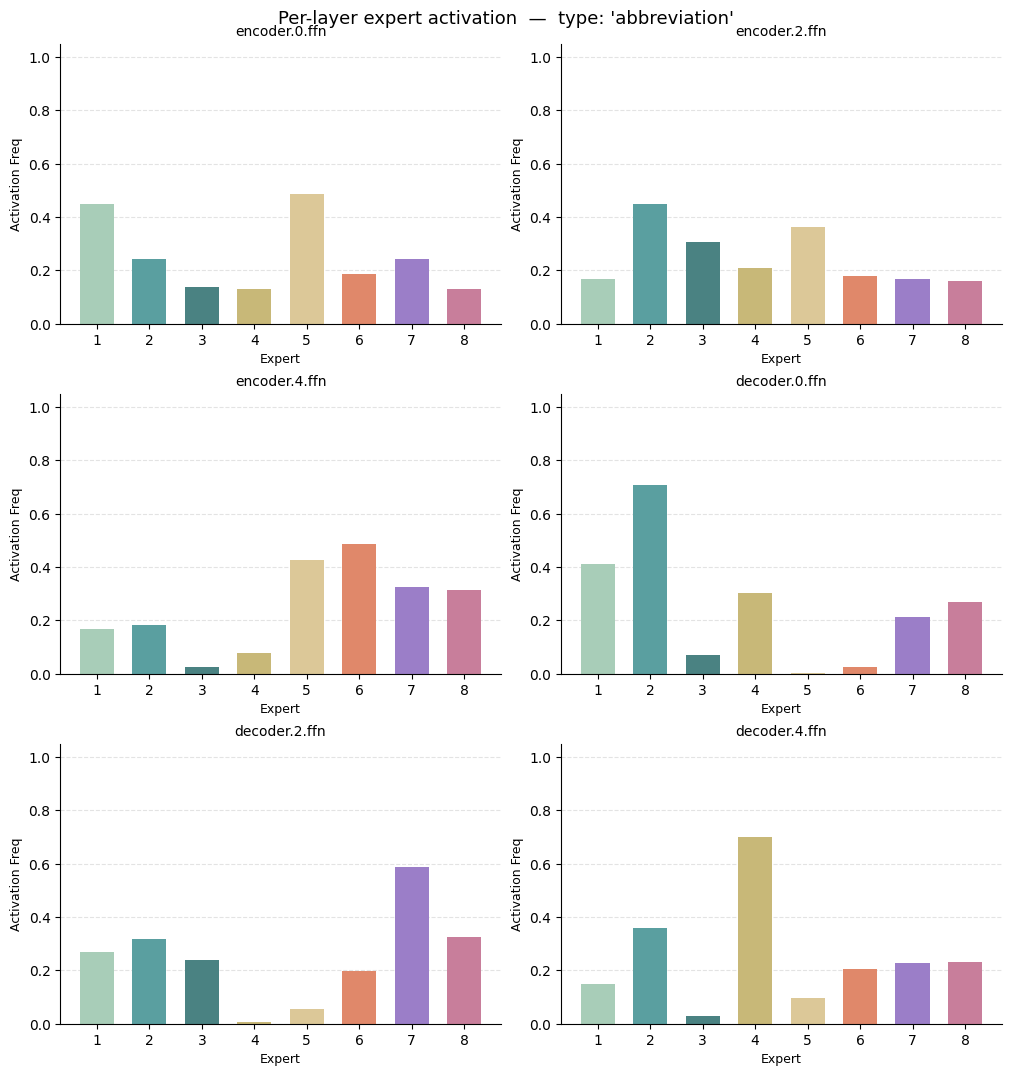

Saved: expert_activation_perlayer_abbreviation.png


In [23]:
TARGET_TYPE = types_sorted[0]    # change to any error type

layer_freq  = type_layer_freq[TARGET_TYPE]
layer_names = list(layer_freq.keys())
n_layers    = len(layer_names)
colors      = (EXPERT_PALETTE * ((E // len(EXPERT_PALETTE)) + 1))[:E]

ncols = 2
nrows = (n_layers + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(10, 3.5 * nrows),
                         facecolor="white", constrained_layout=True)
axes_flat  = np.array(axes).flatten()

for i, (lname, freq) in enumerate(layer_freq.items()):
    ax = axes_flat[i]
    ax.bar(x, freq, color=colors, width=0.65, zorder=2, linewidth=0)
    ax.set_xlim(0.3, E + 0.7)
    ax.set_ylim(0.0, 1.05)
    ax.set_xticks(x)
    ax.set_title(lname, fontsize=10)
    ax.set_xlabel("Expert", fontsize=9)
    ax.set_ylabel("Activation Freq", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    ax.yaxis.grid(True, linestyle="--", alpha=0.35, zorder=0)
    ax.set_axisbelow(True)

for i in range(n_layers, len(axes_flat)):
    axes_flat[i].set_visible(False)

fig.suptitle(f"Per-layer expert activation  —  type: '{TARGET_TYPE}'", fontsize=13, y=1.01)

out_path = f"expert_activation_perlayer_{TARGET_TYPE.replace(' ', '_')}.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")
